In [1]:
import rasterio as rio
import numpy as np
import pandas as pd
import glob
import os
from sklearn.preprocessing import StandardScaler,MinMaxScaler

# widget tools
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from ipywidgets import Output
from IPython.display import display

In [2]:
# reference lidar data
# referencefile = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/depth/SnwDpth_Grnd_Asp_Slp_CPC_CHM_FHD512.tif'
referencefile = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/field_data/depth/SNEX20_GM_Lidar_SD_20200201_20200202_v01.0_UTM12.tif'
file = rio.open(referencefile)
# lidar_DATA = file.read(1) # read in the first and only band (elevations)
lidar_DATA = file.read(1)*100 # convert to cm
# create the 1-m grid
grid_X = np.arange(file.bounds.left+0.5, file.bounds.right,1)
grid_Y = np.arange(file.bounds.top-0.5,file.bounds.bottom,-1)

In [3]:
rd_array_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_processed_bigDrift_rd26to35/' # to rd arrays
rd_output_path = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/' # to output csv files
parameter_combo = '500scale_100size_1.0mod' # set this for all
rd_output_files = glob.glob(rd_output_path+'*'+parameter_combo+'.csv')
rd_output_files.sort()
print(rd_output_files)

# enter in input parameters:
velocity = 2.44e8*100 # enter in velocity to use for depth calculation [cm/s]
# velocity = 2.24e8*100 # enter in velocity to use for depth calculation [cm/s]

# grab TWT interval from TWT_vector
TWT_df = pd.read_csv(rd_array_path+'TWT_vector.csv')
TWT_interval = np.diff(TWT_df.TWT)[0]
print(TWT_interval)

['/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd01_500scale_100size_1.0mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd02_500scale_100size_1.0mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd03_500scale_100size_1.0mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd04_500scale_100size_1.0mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd05_500scale_100size_1.0mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd06_500scale_100size_1.0mod.csv', '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/coords/rd07_500scale_100size_1.0mod.csv']
1.0162353515625e-11


In [4]:
# # MANUALLY SET
final_intercept = 15 # Centimeters
depth_shift = final_intercept
pixel_shift = round(final_intercept*2/velocity/TWT_interval)
print(depth_shift, 'cm  = ',pixel_shift, 'pixels')

15 cm  =  121 pixels


## Examine each radargram

In [5]:
# Loop through radargrams for manual intervention
filtered_outpath = '/Users/jukesliu/Documents/POSTDOC/snow-radar/GM2020/FMCW_wavelet_results_bigDrift_rd26to35/filtered/'
if not os.path.exists(filtered_outpath): # create folder if it doesn't exist already
    os.mkdir(filtered_outpath)

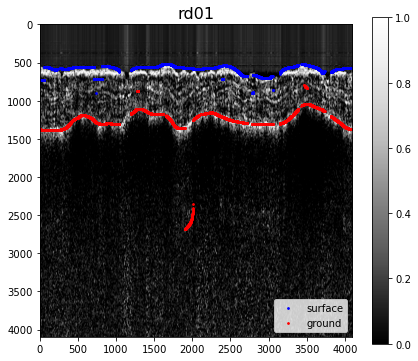

In [6]:
###########################################
CURRENT_RD = 'rd01' # MANUALLY CHANGE THIS
###########################################

rd = np.load(glob.glob(rd_array_path+CURRENT_RD+'_preprocessed.npy')[0]) # read in radagram
coords_df = pd.read_csv(rd_output_path+CURRENT_RD+'_'+parameter_combo+'.csv') # read in the wavelet picks
# normalize the rd values
scaler = MinMaxScaler(feature_range=(0,1)); rd_norm = scaler.fit_transform(rd)

def selection_fn(trace, points, state):
    if points.point_inds:
        # Filter the original DataFrame using the indices
        selected_df = coords_df.iloc[points.point_inds]
        print(points.point_inds) # print the indices to output

# Process surface and ground data separately
# # manipulate the dataframe to plot both variables in plotly, create new data_df
# ground_df = coords_df.copy(); ground_df['yidx'] = ground_df.Iground; ground_df['var_name'] = 'Iground'
# # ground_df
# surface_df = coords_df; surface_df['yidx'] = surface_df.Isurf; surface_df['var_name'] = 'Isurf'
# data_df = pd.concat([surface_df, ground_df])
# data_df.reset_index(drop=True)

# display the original image with delineations
fig, ax = plt.subplots(figsize=(7,6))
im1 = ax.imshow(rd_norm,cmap='Greys_r') # plot radargram
surf_pts = ax.scatter(coords_df.rd_xidx, coords_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(coords_df.rd_xidx, coords_df.Iground-pixel_shift, color='red',s=3)
ax.legend(['surface','ground'],loc='lower right'); fig.colorbar(im1)
ax.set_title(CURRENT_RD,fontsize=16)
plt.show()

## Filter the ground points

In [7]:
# create the plotly widget - for ground points
px_fig = px.imshow(rd_norm, color_continuous_scale='Gray',origin='upper')# SLOW
fig = go.FigureWidget(px.scatter(coords_df, x="rd_xidx", y="Iground", # scatter the df
                 range_y=[rd.shape[1],0], range_x=[0,rd.shape[0]]))
fig.update_traces(marker=dict(color='red'))
fig.add_trace(px_fig.data[0]) # add the radargram to the background - SLOW
fig.update_layout(width=700,height=600) # set figure size
scatter = fig.data[0]
output = Output()

output.capture()

scatter.on_selection(selection_fn) # Attach the selection event handler
display(fig, output)

FigureWidget({
    'data': [{'hovertemplate': 'rd_xidx=%{x}<br>Iground=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': 'red', 'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'showlegend': False,
              'type': 'scattergl',
              'uid': '9550454a-34f6-4ec2-abd1-fcef11c40956',
              'x': array([2.000e+00, 3.000e+00, 4.000e+00, ..., 4.092e+03,       nan,       nan]),
              'xaxis': 'x',
              'y': array([1498., 1499., 1499., ..., 1497.,   nan,   nan]),
              'yaxis': 'y'},
             {'coloraxis': 'coloraxis',
              'hovertemplate': 'x: %{x}<br>y: %{y}<br>color: %{z}<extra></extra>',
              'name': '0',
              'type': 'heatmap',
              'uid': 'fac9bd25-db20-4694-9b21-de60b1fff9c5',
              'xaxis': 'x',
              'yaxis': 'y',
              'z': array([[0.07245226, 0.07245226, 0.07245226, ..., 0.12733047, 0.12733047,

Output()

[1153, 1154, 1155, 1156, 1157, 1158, 1159, 1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1768, 1769, 1770, 1771, 1772, 1773, 1774, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 3236, 3237, 3238, 3239, 3240, 3241, 3242, 3243, 3244, 3245, 3246, 3247, 3248, 3249, 3250, 3251, 3252, 3253, 3254, 3255, 3256, 3257, 3258, 3259, 3260, 3261, 3262, 3263, 3264, 3265, 3266, 3267, 3268]


In [8]:
# delete selection
parsed_indices = output.outputs[0]['text'][1:-2].split(', ') # parse the output strings
coords_df = coords_df.drop(selected_idxs,axis='index') # drop those data points

# reshow to check
fig, ax = plt.subplots(figsize=(7,6))
im1 = ax.imshow(rd_norm,cmap='Greys_r') # plot radargram
surf_pts = ax.scatter(coords_df.rd_xidx, coords_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(coords_df.rd_xidx, coords_df.Iground-pixel_shift, color='red',s=3)
ax.legend(['surface','ground'],loc='lower right'); fig.colorbar(im1)
ax.set_title(CURRENT_RD,fontsize=16)
plt.show()

IndexError: tuple index out of range

In [10]:
output

Output()

## Filter the surface points

In [ ]:
# create the plotly widget - for surface points
fig = []; scatter = []; output = [] # clear original data
fig = go.FigureWidget(px.scatter(coords_df, x="rd_xidx", y="Isurf", # scatter the df
                 range_y=[rd.shape[1],0], range_x=[0,rd.shape[0]]))
fig.update_traces(marker=dict(color='blue'))
fig.add_trace(px_fig.data[0]) # add the radargram to the background - SLOW
fig.update_layout(width=700,height=600) # set figure size
scatter = fig.data[0]
output = Output()

output.capture()
scatter.on_selection(selection_fn) # Attach the selection event handler
display(fig, output)

In [ ]:
# delete selection
parsed_indices = output.outputs[0]['text'][1:-2].split(', ') # parse the output strings
selected_idxs = np.array(parsed_indices,dtype=int) # convert to integers
print(selected_idxs)
coords_df = coords_df.drop(selected_idxs,axis='index') # drop those data points

# reshow to check
fig, ax = plt.subplots(figsize=(7,6))
im1 = ax.imshow(rd_norm,cmap='Greys_r') # plot radargram
surf_pts = ax.scatter(coords_df.rd_xidx, coords_df.Isurf, color='blue',s=3)
ground_pts = ax.scatter(coords_df.rd_xidx, coords_df.Iground-pixel_shift, color='red',s=3)
ax.legend(['surface','ground'],loc='lower right'); fig.colorbar(im1)
ax.set_title(CURRENT_RD,fontsize=16)
plt.show()

In [ ]:
filtered_df = coords_df

## Additional filtering: Crop out points by index

In [ ]:
# OPTIONAL - filter out by x index
# filtered_df = filtered_df[filtered_df.rd_xidx < 4000] # right edge
filtered_df = filtered_df[filtered_df.rd_xidx > 4600] # left edge

plt.scatter(filtered_df.rd_xidx, filtered_df.Iground, s=2) # plot filtered pts in light blue over rd
plt.show()

In [ ]:
# OPTIONAL filter by surface depth (vertical index)
filtered_df = filtered_df[filtered_df.Isurf <= 680]

plt.scatter(filtered_df.rd_xidx, filtered_df.Isurf, s=2) # plot filtered pts in light blue over rd
plt.show()

In [ ]:
# OPTIONAL - filter by ground depth (vertical index)
filtered_df = filtered_df[filtered_df.Iground-pixel_shift >= 860]

plt.scatter(filtered_df.rd_xidx, filtered_df.Iground, s=2) # plot filtered pts in light blue over rd
plt.show()

### Save final filtered df

In [ ]:
# save
filtered_df.to_csv(filtered_outpath+CURRENT_RD+'_'+parameter_combo+'_filtered.csv') # write to CSV